In [1]:

# EncoderX Internship - Task 4
# HR Analytics Interactive Dashboard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


Upload the dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


###Dataset Inspection/Statistics

###Shape of Dataset

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 35)


In [5]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


Number of Rows: 1470
Number of Columns: 35


In [10]:
print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. Age
2. Attrition
3. BusinessTravel
4. DailyRate
5. Department
6. DistanceFromHome
7. Education
8. EducationField
9. EmployeeCount
10. EmployeeNumber
11. EnvironmentSatisfaction
12. Gender
13. HourlyRate
14. JobInvolvement
15. JobLevel
16. JobRole
17. JobSatisfaction
18. MaritalStatus
19. MonthlyIncome
20. MonthlyRate
21. NumCompaniesWorked
22. Over18
23. OverTime
24. PercentSalaryHike
25. PerformanceRating
26. RelationshipSatisfaction
27. StandardHours
28. StockOptionLevel
29. TotalWorkingYears
30. TrainingTimesLastYear
31. WorkLifeBalance
32. YearsAtCompany
33. YearsInCurrentRole
34. YearsSinceLastPromotion
35. YearsWithCurrManager


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
categorical_columns = df.select_dtypes(include='object').columns

df[categorical_columns].describe().T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


##Data quality assessment

###Missing Values

In [13]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values['Missing Values'] > 0]

if missing_values.empty:
    print("No missing values found.")
else:
    display(missing_values)

No missing values found.


###Duplictae Records

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Uniques Values

In [14]:
print("Unique Values in Each Column:\n")

for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

Unique Values in Each Column:

Age: 43
Attrition: 2
BusinessTravel: 3
DailyRate: 886
Department: 3
DistanceFromHome: 29
Education: 5
EducationField: 6
EmployeeCount: 1
EmployeeNumber: 1470
EnvironmentSatisfaction: 4
Gender: 2
HourlyRate: 71
JobInvolvement: 4
JobLevel: 5
JobRole: 9
JobSatisfaction: 4
MaritalStatus: 3
MonthlyIncome: 1349
MonthlyRate: 1427
NumCompaniesWorked: 10
Over18: 1
OverTime: 2
PercentSalaryHike: 15
PerformanceRating: 2
RelationshipSatisfaction: 4
StandardHours: 1
StockOptionLevel: 4
TotalWorkingYears: 40
TrainingTimesLastYear: 7
WorkLifeBalance: 4
YearsAtCompany: 37
YearsInCurrentRole: 19
YearsSinceLastPromotion: 16
YearsWithCurrManager: 18


###Identifictaion of  unnecessary columns

In [15]:
columns_to_check = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

for column in columns_to_check:
    if column in df.columns:
        print(f"\n{column}")
        print(df[column].value_counts())


EmployeeCount
EmployeeCount
1    1470
Name: count, dtype: int64

EmployeeNumber
EmployeeNumber
2068    1
1       1
2       1
4       1
5       1
       ..
23      1
22      1
21      1
20      1
19      1
Name: count, Length: 1470, dtype: int64

Over18
Over18
Y    1470
Name: count, dtype: int64

StandardHours
StandardHours
80    1470
Name: count, dtype: int64


###Creating a working copy

In [16]:
# Create a working copy
hr_df = df.copy()

print("Original Dataset Shape:", df.shape)
print("Working Dataset Shape:", hr_df.shape)

Original Dataset Shape: (1470, 35)
Working Dataset Shape: (1470, 35)


###Removing unnecessary columns

In [17]:
# Columns that do not provide analytical value
columns_to_drop = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

hr_df.drop(columns=columns_to_drop, inplace=True)

print("Unnecessary columns removed successfully.")
print("Updated Dataset Shape:", hr_df.shape)

Unnecessary columns removed successfully.
Updated Dataset Shape: (1470, 31)


###Verifying missing values

In [18]:
missing_values = hr_df.isnull().sum()

print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


###Verifying duplicate records

In [19]:
print("Duplicate Rows:", hr_df.duplicated().sum())

Duplicate Rows: 0


Checking data types

In [20]:
hr_df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object


###Checking categorical values

In [21]:
categorical_columns = hr_df.select_dtypes(
    include=['object']
).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(hr_df[column].value_counts())


Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673


#Feature engineering

###Age Groups

In [22]:
hr_df['AgeGroup'] = pd.cut(
    hr_df['Age'],
    bins=[17, 25, 35, 45, 55, 65],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65']
)

###Income Groups

In [23]:
hr_df['IncomeGroup'] = pd.cut(
    hr_df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, float('inf')],
    labels=['Low Income', 'Lower-Middle Income',
            'Upper-Middle Income', 'High Income']
)

###Tenure Groups

In [24]:
hr_df['TenureGroup'] = pd.cut(
    hr_df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 20, float('inf')],
    labels=['0-2 Years', '3-5 Years',
            '6-10 Years', '11-20 Years', '20+ Years']
)

###Verifying new features

In [25]:
new_columns = ['AgeGroup', 'IncomeGroup', 'TenureGroup']

hr_df[new_columns].head(10)

,AgeGroup,IncomeGroup,TenureGroup
0,36-45,Lower-Middle Income,6-10 Years
1,46-55,Lower-Middle Income,6-10 Years
2,36-45,Low Income,0-2 Years
3,26-35,Low Income,6-10 Years
4,26-35,Lower-Middle Income,0-2 Years
5,26-35,Lower-Middle Income,6-10 Years
6,56-65,Low Income,0-2 Years
7,26-35,Low Income,0-2 Years
8,36-45,Upper-Middle Income,6-10 Years
9,36-45,Lower-Middle Income,6-10 Years


###Final dataset check

In [26]:
print("Final Dataset Shape:", hr_df.shape)

print("\nMissing Values:")
print(hr_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(hr_df.duplicated().sum())

hr_df.head()

Final Dataset Shape: (1470, 34)

Missing Values:
0

Duplicate Rows:
0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,IncomeGroup,TenureGroup
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,8,0,1,6,4,0,5,36-45,Lower-Middle Income,6-10 Years
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,10,3,3,10,7,1,7,46-55,Lower-Middle Income,6-10 Years
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,7,3,3,0,0,0,0,36-45,Low Income,0-2 Years
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,8,3,3,8,7,3,0,26-35,Low Income,6-10 Years
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,6,3,3,2,2,2,2,26-35,Lower-Middle Income,0-2 Years


#Exploratory Data Analysis (EDA)

###Overall employee and attrition distribution

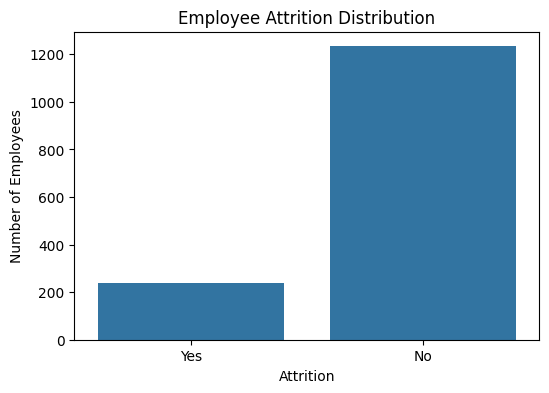

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [27]:
# Attrition distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=hr_df, x='Attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

print(hr_df['Attrition'].value_counts())

###Employee distribution by department

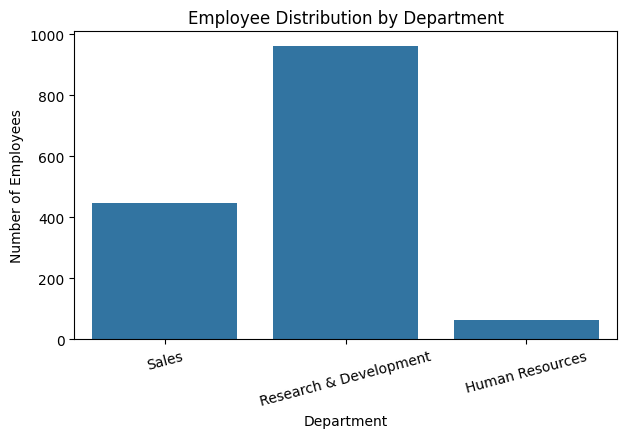

In [28]:
plt.figure(figsize=(7, 4))

sns.countplot(data=hr_df, x='Department')

plt.title('Employee Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=15)
plt.show()

###Attrition by department

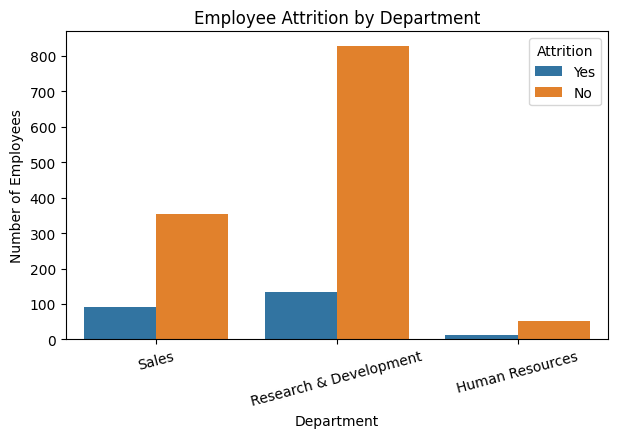

In [29]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=hr_df,
    x='Department',
    hue='Attrition'
)

plt.title('Employee Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=15)
plt.show()

###Attrition by age group

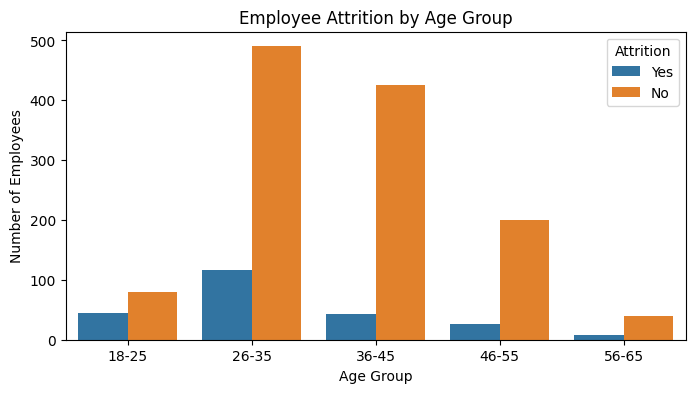

In [30]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=hr_df,
    x='AgeGroup',
    hue='Attrition',
    order=['18-25', '26-35', '36-45', '46-55', '56-65']
)

plt.title('Employee Attrition by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.show()

#HR KPI calculations

###Calculating all five KPI

In [31]:
# HR KPI Calculations

total_employees = len(hr_df)

employees_left = (hr_df['Attrition'] == 'Yes').sum()

attrition_rate = (employees_left / total_employees) * 100

avg_monthly_income = hr_df['MonthlyIncome'].mean()

avg_years_at_company = hr_df['YearsAtCompany'].mean()

# Display KPIs
hr_kpis = pd.DataFrame({
    'KPI': [
        'Total Employees',
        'Employees Left',
        'Attrition Rate',
        'Average Monthly Income',
        'Average Years at Company'
    ],
    'Value': [
        total_employees,
        employees_left,
        f"{attrition_rate:.2f}%",
        f"${avg_monthly_income:,.2f}",
        f"{avg_years_at_company:.2f} Years"
    ]
})

display(hr_kpis)

,KPI,Value
0,Total Employees,1470
1,Employees Left,237
2,Attrition Rate,16.12%
3,Average Monthly Income,"$6,502.93"
4,Average Years at Company,7.01 Years


In [32]:
# Export cleaned HR dataset
hr_df.to_csv('HR_Analytics_Cleaned.csv', index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [33]:
from google.colab import files

files.download('HR_Analytics_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
hr_kpis.to_csv('HR_KPI_Summary.csv', index=False)

files.download('HR_KPI_Summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>